# 08 · Working with any EDA frontend

`07_choosing_an_engine` showed one job running on three *engines*. This is the
mirror image: **one engine-agnostic `Component`, reached from any layout
*frontend*.** However your geometry is authored — programmatically in
gdsfactory, in a KLayout/SiEPIC foundry PDK, as a plain GDS from any tool, or
passed through a lithography model — gds_fdtd ingests it, **auto-detects the
ports**, and hands you the *same* `Component`. From there, everything
downstream (mode, mesh, `SimulationSpec`, `get_solver`, `run`) is identical.

| Frontend | How you get geometry | Entry point |
|----------|----------------------|-------------|
| **gdsfactory** | parametric Python components (PDK) | `layout.gdsfactory.from_gdsfactory` |
| **KLayout / SiEPIC** | a foundry PDK cell | `lyprocessor.load_cell` → `load_component_from_tech` |
| **raw GDS** | any `.gds` from any tool | `lyprocessor.load_cell` → `load_component_from_tech` |
| **PreFab** | a lithography-predicted GDS | `lyprocessor.load_device(prefab_model=…)` |

All of this is **offline and free** — no engine runs here.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt

from gds_fdtd.lyprocessor import load_cell
from gds_fdtd.plotting import plot_component
from gds_fdtd.simprocessor import load_component_from_tech
from gds_fdtd.spec import SimulationSpec
from gds_fdtd.technology import Technology


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)


tech = Technology.from_yaml(_find("examples/tech.yaml"))
components = {}  # frontend name -> Component

## 1 · gdsfactory — parametric, programmatic

[gdsfactory](https://gdsfactory.github.io/gdsfactory/) builds components in
Python. `from_gdsfactory` reads the polygons on each technology layer and
lifts the gdsfactory ports into gds_fdtd ports.

In [2]:
import gdsfactory as gf  # noqa: E402

from gds_fdtd.layout.gdsfactory import from_gdsfactory  # noqa: E402

gf.gpdk.PDK.activate()
components["gdsfactory\nmmi1x2"] = from_gdsfactory(gf.components.mmi1x2(), tech)

17:11:24 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

## 2 · KLayout / SiEPIC — a foundry PDK

The same reader consumes a cell straight from the SiEPIC EBeam PDK (the
`ebeam_y_1550` y-branch) — the KLayout pin + DevRec conventions become ports
and bounds automatically. This is the path most silicon-photonics tapeouts
use, and (thanks to the shim in `solvers/beamz`) it feeds *every* engine.

In [3]:
try:
    import siepic_ebeam_pdk as pdk

    gds = os.path.join(os.path.dirname(pdk.__file__), "gds", "EBeam", "ebeam_y_1550.gds")
    cell, _ = load_cell(gds, top_cell="ebeam_y_1550")
    components["SiEPIC\nebeam_y_1550"] = load_component_from_tech(cell=cell, tech=tech)
except ImportError:
    print("(install siepic_ebeam_pdk to load the SiEPIC PDK cell)")

SiEPIC-EBeam-PDK Python module: siepic_ebeam_pdk, KLayout technology: EBeam
KLayout SiEPIC-Tools version 0.5.31
SiEPIC-Tools is up to date (0.5.31 vs 0.5.31).
Version check, time: 0.19630646705627441 seconds


SiEPIC-EBeam-PDK Python module: pymacros, v0.4.53
Libraries associated with Technology EBeam: ['EBeam', 'EBeam-ANT', 'EBeam-Dream', 'EBeam-SiN', 'EBeam_Beta']


## 3 · A raw GDS file — from any tool

No PDK, no framework: point `load_cell` at any `.gds`. Here, a waveguide
crossing shipped with these examples. As long as the polygons land on the
technology's device/pin/DevRec layers, ports are detected the same way.

In [4]:
cell, _ = load_cell(str(_find("examples/devices.gds")), top_cell="crossing_te1550")
components["raw GDS\ncrossing"] = load_component_from_tech(cell=cell, tech=tech)

## 4 · PreFab — lithography-aware geometry

[PreFab](https://www.prefabphotonics.com/) predicts how a nanofabrication
process will *actually* print your design (corner rounding, proximity
effects). `load_device` runs the model and writes a `<cell>_predicted.gds`,
which you then load like any other GDS — so the litho-predicted shape flows
into the identical simulation path. It needs a PreFab account, so we show the
call rather than run it here:

```python
from gds_fdtd.lyprocessor import load_device
# writes <top_cell>_predicted.gds next to output_dir, then loads it:
predicted = load_device(
    "my_design.gds", tech=tech, top_cell="my_cell",
    prefab_model="ANT_NanoSOI_ANF1_d10", output_dir="out/",
)
```

See `07_prefab` for the full lithography-to-simulation example.

## The payoff — one `Component`, one API

Every frontend produced the same kind of object: device polygons + auto-detected
ports + bounds. Below, each device rendered with the standard geometry view.

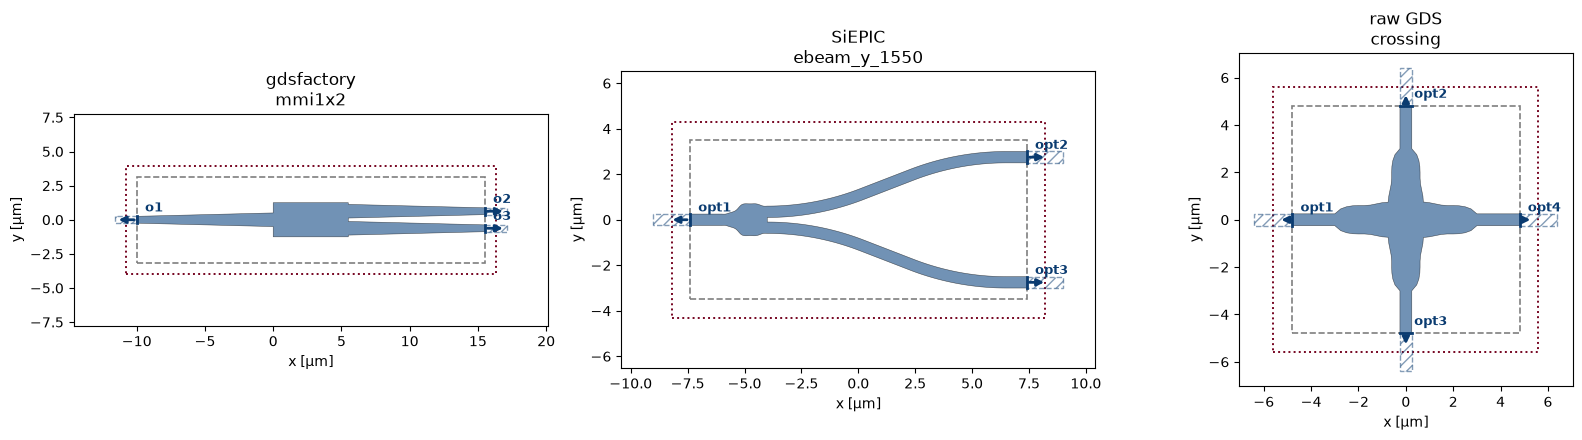

gdsfactory mmi1x2       : 3 ports ['o1', 'o2', 'o3']
SiEPIC ebeam_y_1550     : 3 ports ['opt1', 'opt2', 'opt3']
raw GDS crossing        : 4 ports ['opt1', 'opt4', 'opt2', 'opt3']


In [5]:
n = len(components)
fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4.5))
axes = axes if n > 1 else [axes]
for ax, (name, comp) in zip(axes, components.items(), strict=True):
    plot_component(comp, spec=SimulationSpec(buffer=0.8), ax=ax)
    ax.set_title(name)
    ax.legend().set_visible(False)
fig.tight_layout()
plt.show()

for name, comp in components.items():
    label = name.replace("\n", " ")
    print(f"{label:24s}: {len(comp.ports)} ports {[p.name for p in comp.ports]}")

Because the frontend only produces a `Component`, the rest of the toolbox
doesn't care where it came from. Any of these drives any engine with the same
call — here we just confirm one builds offline, for free:

In [6]:
from gds_fdtd.solvers import get_solver  # noqa: E402

demo = next(iter(components.values()))
solver = get_solver("beamz")(demo, technology=tech, spec=SimulationSpec(wavelength_points=3, mesh=5))
print(f"{demo.name}: validate() -> {solver.validate() or 'OK'}")
print("build() summary:", solver.build().summary)

mmi1x2_gdsfactorypcomponentspmmispmmi1x2_WNone_WT1_LT10_1f097353: validate() -> OK
● Info: Auto-selecting 3D meshing for 3D design
● Rasterizing 3D structures...
● Rasterizing 3D structures... done (2/2)
● Info: 3D raster timing: setup=0.02s, structures=0.03s, pml=0.00s, total=0.06s
● Info: 3D raster kernels: fast_enabled=True, fast_rect=0, fast_poly=1, fallback=0
● Done: Created 3D mesh: 353 × 95 × 58 cells


● Info: Raster cache saved: 7c8082b23913b3ea511a57315332bd61a82978751048d8eb44a83e4464b235c9.npz | save=0.25s
● Info: Rasterize wall-time: 0.06s | total=0.31s
build() summary: {'n_ports': 3, 'grid_shape': (58, 95, 353), 'dx_nm': 89.18296892980437, 'n_core': 3.476, 'n_clad': 1.444, 'n_simulations': 3}


## Recap & next

gds_fdtd sits behind a single geometry abstraction, so your EDA choice and
your FDTD-engine choice are independent — mix and match freely.

- **`07_choosing_an_engine`** — the other axis: one Component, three engines.
- **`10_cookbook`** — reference devices (crossing, coupler, ring) end to end.